In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import re
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

In [9]:
os.chdir('/Users/tergemina/Library/CloudStorage/Dropbox/backup/Jupyter/Methylome/')

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

# Load GWAS and kmerGWAS results for CpG_genes

In [19]:
df = pd.read_table('CpG_genes.assoc.txt')
df['P'] = -(np.log10(df['p_lrt']))
space=2000000
df['position'] = np.select([df['chr'] == 1, df['chr'] == 2, df['chr'] == 3, df['chr'] == 4, df['chr'] == 5],
                    [df['ps'], 
                    df['ps'] + 30427671 + space, 
                    df['ps'] + 30427671 + 19698289 + space * 2,
                    df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                    df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
snp=df
snp.head()

,chr,rs,ps,n_miss,allele1,allele0,af,l_mle,p_lrt,P,position
0,1,1:24018,24018,0,T,G,0.120,11.78519,0.817377,0.087578,24018
1,1,1:34055,34055,1,G,T,0.220,11.97898,0.340083,0.468415,34055
2,1,1:56571,56571,1,C,T,0.098,11.63205,0.473822,0.324385,56571
3,1,1:59491,59491,0,A,T,0.072,11.67350,0.533100,0.273191,59491
4,1,1:73205,73205,1,G,A,0.122,11.74158,0.991563,0.003680,73205


In [23]:
df = pd.read_table('CpG_genes.kmers.assoc.txt')
df['Chr_S1-1'] = df['Chr_S1-1'].str.lower()
df = df[df['Chr_TAIR10'] == df['Chr_S1-1']]
df = df[df['MP_TAIR10'] >= 24]
df['P'] = -(np.log10(df['p_lrt']))

space=2000000
df['position'] = np.select([df['Chr_TAIR10'] == 'chr1', df['Chr_TAIR10'] == 'chr2', df['Chr_TAIR10'] == 'chr3', df['Chr_TAIR10'] == 'chr4', df['Chr_TAIR10'] == 'chr5'],
[df['Pos_TAIR10'], 
df['Pos_TAIR10'] + 30427671 + space, 
df['Pos_TAIR10'] + 30427671 + 19698289 + space * 2,
df['Pos_TAIR10'] + 30427671 + 19698289 + 23459830 + space * 3,
df['Pos_TAIR10'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
kmer=df
kmer.head()

,chr,rs,ps,n_miss,allele1,allele0,af,l_mle,p_lrt,Chr_TAIR10,...,Pos_S15_3,MQ_S15_3,Chr_S5_10,Pos_S5_10,MQ_S5_10,Chr_Cvi-0,Pos_Cvi-0,MQ_Cvi-0,P,position
0,0,AAAAAAAAAAATAATTAAAAACATGGAAGCA_8064,0,0,0,1,0.469,100000.0,2.476924e-14,chr1,...,27409412,42,Chr1,27387426,24,Chr1,27385940,24,13.606087,26835570
2,0,AAAAAAAAAAATTTTAAAAAAAAAAATGAAT_6792,0,0,0,1,0.506,100000.0,1.254779e-14,chr1,...,25104252,24,Chr1,25085862,42,Chr1,25083620,42,13.901433,24537894
3,0,AAAAAAAAAATAATTAAAAACATGGAAGCAA_8176,0,0,0,1,0.469,100000.0,2.476924e-14,chr1,...,27409411,42,Chr1,27387425,24,Chr1,27385939,24,13.606087,26835569
6,0,AAAAAAAAAATTTTAAAAAAAAAAATGAATT_6785,0,0,0,1,0.506,100000.0,1.254779e-14,chr1,...,25104251,24,Chr1,25085861,42,Chr1,25083619,42,13.901433,24537893
8,0,AAAAAAAAATAATTAAAAACATGGAAGCAAA_8162,0,0,0,1,0.469,100000.0,2.476924e-14,chr1,...,27409410,42,Chr1,27387424,24,Chr1,27385938,24,13.606087,26835568


# Fig2a

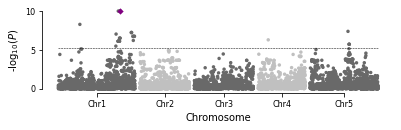

In [20]:
top_SNP=snp.loc[(snp['chr'] == 1) &
                          (snp['ps'] == 24622585)]
# top_SNP.head()
cm = 1/2.54
fig = plt.figure(figsize=(16*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=snp,
                hue='chr',
                palette=['dimgray','silver','dimgray','silver','dimgray'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False)
ax = sns.scatterplot(x='ps',
                y='P',
                data=top_SNP,
                color='purple',
                marker='D',
                s=20,
                linewidth=0)
plt.hlines(y=5.3,
             xmin=min(snp['position']),
             xmax=max(snp['position']),
             color='0',
             linestyle='--',
             linewidth=0.5,
#              alpha=0.4,
             zorder=6)
# ax.hlines(x)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
# plt.ylim(0,20)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("Fig2a_20250610.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig2a_20250610.pdf", format="pdf",bbox_inches="tight")

# Fig2b

In [25]:
kmer['CVI-0_mapped']=np.select([kmer['Chr_Cvi-0'] == '*'],
                                        ['No'],'Yes')
kmer.sort_values(by=['P'],ascending=False).head(5)

,chr,rs,ps,n_miss,allele1,allele0,af,l_mle,p_lrt,Chr_TAIR10,...,MQ_S15_3,Chr_S5_10,Pos_S5_10,MQ_S5_10,Chr_Cvi-0,Pos_Cvi-0,MQ_Cvi-0,P,position,CVI-0_mapped
3350,0,ACTTTTATCGGATGTCGTTTATGGCTCTAAA_1371,0,0,0,1,0.469,100000.0,8.860048e-19,chr1,...,42,Chr1,25171226,24,Chr1,25168987,24,18.052564,24626718,Yes
9437,0,TCACCGAGAGTTACCGGTTTAACCGATAGAA_2133,0,0,0,1,0.469,100000.0,8.860048e-19,chr1,...,42,Chr1,25167088,24,Chr1,25164849,24,18.052564,24622578,Yes
5108,0,ATGTCTTCTCAAGAGTTCTTCCTCAATAGAG_2724,0,0,0,1,0.469,100000.0,8.860048e-19,chr1,...,42,*,0,0,*,0,0,18.052564,24588454,No
5111,0,ATGTGCATCTTTTTCCATTCATTGACTGGAG_1578,0,0,0,1,0.469,100000.0,8.860048e-19,chr1,...,42,*,0,0,*,0,0,18.052564,24588147,No
6995,0,CGTTTATGGCTCTAAAAATTTACTGCGCATA_889,0,0,0,1,0.469,100000.0,8.860048e-19,chr1,...,42,*,0,0,*,0,0,18.052564,24626703,No


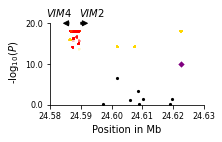

In [32]:
start = 24580000
end = 24625000
top_SNP=snp.loc[(snp['chr'] == 1) &
                          (snp['ps'] == 24622585)]

Chr1_zoom_CpG_genes_kmer = kmer.loc[(kmer['Chr_TAIR10'] == 'chr1') &
                          (kmer['Pos_TAIR10'] > start) &
                          (kmer['Pos_TAIR10'] < end)]
Chr1_CpG_genes_zoom = snp.loc[(snp['chr'] == 1) &
                (snp['ps'] > start) &
                (snp['ps'] < end)]
                                         
def major_formatter(x, pos):
    y = x /1000000
    return "%.2f" % y
cm = 1/2.54
fig = plt.figure(figsize=(7*cm,4*cm))
ax=sns.scatterplot(x='Pos_TAIR10',
                y='P',
                data=Chr1_zoom_CpG_genes_kmer,
                marker='+',
                hue='CVI-0_mapped',
                s=10,
                legend=False,
                hue_order=['Yes','No'],
                palette=["gold", "red"])
ax=sns.scatterplot(x='ps',
                y='P',
                data=Chr1_CpG_genes_zoom,
                palette='cividis',
#                 hue='r2',
                color='0',
                marker='o',
                s=10,
                linewidth=0)
ax=sns.scatterplot(x='ps',
                y='P',
                data=top_SNP,
                palette='cividis',
#                 hue='r2',
                color='purple',
                marker='D',
                s=20,
                linewidth=0)
ax.annotate(r'$\itVIM4$',xy=(24586760, 21),xytext=(24586760-8000,21.5))
ax.annotate(r'$\itVIM2$',xy=(24589343, 21),xytext=(24589343,21.5))
ax.xaxis.set_major_formatter(major_formatter)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(10000))
plt.xlabel('Position in Mb',fontsize=10)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
arrow1 = mpatches.FancyArrowPatch((24586760, 20), (24583740, 20),mutation_scale=10,color='0')
ax.add_patch(arrow1)
arrow2 = mpatches.FancyArrowPatch((24589343, 20), (24592780, 20),mutation_scale=10,color='0')
ax.add_patch(arrow2)

# ax.vlines(24586760,0,19,colors='r',zorder=0,linewidth=1)

plt.xlim(start,end+5000)
plt.ylim(0,21)
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("Fig2b_20250610.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig2b_20250610.pdf", format="pdf",bbox_inches="tight")

# Sup Figure 1

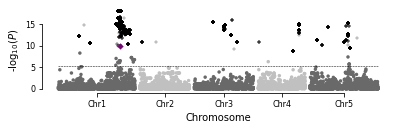

In [34]:
top_SNP=snp.loc[(snp['chr'] == 1) &
                          (snp['ps'] == 24622585)]
cm = 1/2.54
fig = plt.figure(figsize=(16*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=snp,
                hue='chr',
                palette=['dimgray','silver','dimgray','silver','dimgray'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False)
ax = sns.scatterplot(x='ps',
                y='P',
                data=top_SNP,
                color='purple',
                marker='D',
                s=20,
                linewidth=0)
ax = sns.scatterplot(x='position',
                        y='P',
                        data=kmer,
                        color='0',
                        marker='+',
                        s=10,
#                         linewidth=0,
                        legend=False)
plt.hlines(y=5.3,
             xmin=min(snp['position']),
             xmax=max(snp['position']),
             color='0',
             linestyle='--',
             linewidth=0.5,
#              alpha=0.4,
             zorder=6)
# ax.hlines(x)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
# plt.ylim(0,20)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("SupFig1_20250510.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("SupFig1_20250510.pdf", format="pdf",bbox_inches="tight")